# Part 1 — Foundations & Data Handling

**PyTimeSeries user guide** · *Time-indexed data, the shared dataset, and the pytimeseries entry points.*

> Uses the `pytimeseries` package on the shared commodity-price dataset.

In [1]:
import warnings; warnings.simplefilter("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pytimeseries as pt
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Shared dataset: 356 months of global commodity prices (1992-2021)
raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]); df.index = dates
df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]
print("pytimeseries", pt.__version__, "| series:", list(df.columns))

pytimeseries 0.5.0 | series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


This user guide demonstrates the **pytimeseries** package across the 12 parts of the Time Series Analysis course, all on one dataset. Part 1 loads the data and shows the basic handling; `pytimeseries` also ships a synthetic generator.

In [2]:
df.head(3)

,Urea_Price,MP_Price,TSP_Price,Maize_Price,Rice_Price,Wheat_Price,Food_Price_Index,Energy_Price_Index,VIX_Index
date,,,,,,,,,
1992-01-01,122.5,110.0,120.0,109.3,277.3,170.0,55.7,23.7,17.7
1992-02-01,120.6,110.0,120.0,113.6,278.3,177.1,55.5,23.8,17.5
1992-03-01,120.0,110.0,120.0,117.0,277.2,169.4,55.6,23.8,17.5


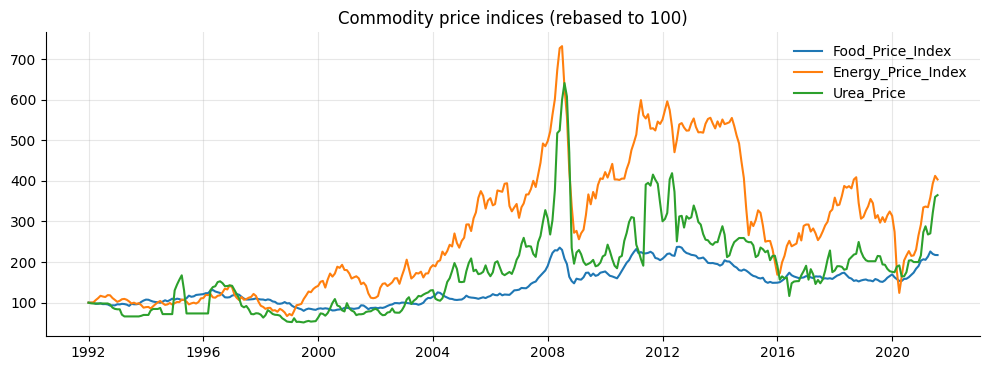

In [3]:
fig, ax = plt.subplots()
for c in ['Food_Price_Index','Energy_Price_Index','Urea_Price']:
    ax.plot(df.index, df[c]/df[c].iloc[0]*100, label=c)
ax.set_title('Commodity price indices (rebased to 100)'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [4]:
# resample & roll — standard pandas handling
df['Food_Price_Index'].resample('YE').mean().tail(3)

date
2019-12-31     86.991667
2020-12-31     92.525000
2021-12-31    119.062500
Freq: YE-DEC, Name: Food_Price_Index, dtype: float64

In [5]:
# pytimeseries synthetic generators for quick experiments
s = pt.datasets.make_series(n=120); panel = pt.datasets.make_panel(n_series=3)
print('make_series:', s.shape, '| make_panel ids:', panel['unique_id'].nunique())

make_series: (120,) | make_panel ids: 3


**Takeaway.** Everything downstream forecasts `y = df['Food_Price_Index']` and is scored with the same walk-forward backtest — so every method is comparable.